In [1]:
import warnings
import sys
import os
import time
import argparse
import nibabel as nib
from mpi4py import MPI
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import squareform, pdist
from sklearn.preprocessing import StandardScaler
from brainiak.searchlight.searchlight import Searchlight
import matplotlib.pyplot as plt
from nilearn import image, plotting, datasets
from ants import image_read, image_write, apply_transforms
import nilearn
from nilearn.image import resample_to_img
from nilearn import plotting
from surfplot import Plot
from matplotlib.colors import ListedColormap
from os.path import join, exists
import ast
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from neuromaps.datasets import fetch_fslr
from matplotlib.colors import Normalize
import numpy as np
from pyvirtualdisplay import Display
import os
# Now your original code
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from surfplot import Plot
import vtk
from neuromaps import transforms
from neuromaps.datasets import fetch_annotation
vtk.vtkObject.GlobalWarningDisplayOff()
from neuromaps.datasets import fetch_fslr

# Surface plotting code

In [2]:
import nibabel as nib
from pyvirtualdisplay import Display
from neuromaps import transforms
from surfplot import Plot
from neuromaps.datasets import fetch_fslr

def create_surface_plot(glm_dir, contrast, output_filename='brain_plot.png', 
                       cmap='YlOrBr_r', dpi=300, display_size=(1024, 768)):
    """
    Create a surface plot of neuroimaging data transformed to fsLR space.
    
    Parameters:
    -----------
    glm_dir : str
        Directory containing GLM analysis results
    contrast : str
        Name of the contrast (e.g., 'visual-audio')
    output_filename : str, optional
        Name of the output file (default: 'brain_plot.png')
    cmap : str, optional
        Colormap for the plot (default: 'YlOrBr_r')
    dpi : int, optional
        Resolution for saved figure (default: 300)
    display_size : tuple, optional
        Size of virtual display (default: (1024, 768))
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure object
    """
    
    # Start virtual display
    display = Display(visible=0, size=display_size)
    display.start()
    
    try:
        # Construct file path
        fn = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
        
        # Load and transform the data
        nii = nib.load(fn)
        
        # Transform results to fsLR space
        fslr = transforms.mni152_to_fslr(nii, '164k')
        fslr_lh, fslr_rh = fslr
        
        # Create the surface plot
        surfaces = fetch_fslr(density='164k')
        lh, rh = surfaces['inflated']
        
        p = Plot(surf_lh=lh, surf_rh=rh)
        p.add_layer({'left': fslr_lh, 'right': fslr_rh}, cmap=cmap)
        
        fig = p.build()
        fig.show()
        
        if output_filename:
            fig.savefig(output_filename, dpi=dpi, bbox_inches='tight')
        
        return fig
        
    finally:
        # Always stop virtual display, even if an error occurs
        display.stop()

# GLM Whole-Brain Plotting

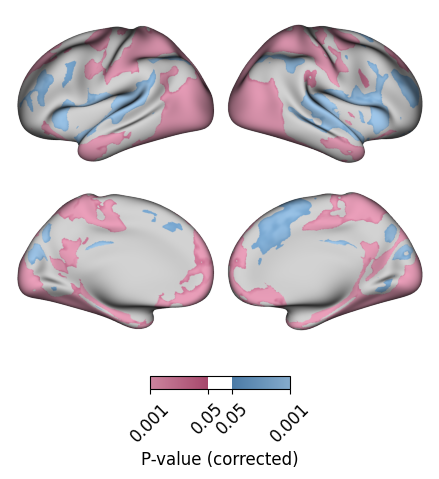

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"
contrast = "audio-visual"

# Load both positive and negative results (stored as 1-p in FSL)
fn_pos = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_neg = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat2.nii.gz"

nii_pos = nib.load(fn_pos)
nii_neg = nib.load(fn_neg)

# Convert from (1-p) to p for both
nii_pos_p = image.math_img('1 - X', X=nii_pos)
nii_neg_p = image.math_img('1 - X', X=nii_neg)

# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)

# Transform results to fslr space FIRST
fslr_pos = transforms.mni152_to_fslr(nii_pos_p, '164k')
fslr_neg = transforms.mni152_to_fslr(nii_neg_p, '164k')

# Extract data arrays
fslr_lh_pos = fslr_pos[0].darrays[0].data.copy()
fslr_rh_pos = fslr_pos[1].darrays[0].data.copy()
fslr_lh_neg = fslr_neg[0].darrays[0].data.copy()
fslr_rh_neg = fslr_neg[1].darrays[0].data.copy()

# Threshold and create signed data
# Positive (audio > visual): keep where p < 0.05, cap at p_max
fslr_lh_pos[fslr_lh_pos > p_threshold] = np.nan
fslr_rh_pos[fslr_rh_pos > p_threshold] = np.nan
fslr_lh_pos[fslr_lh_pos < p_max] = p_max
fslr_rh_pos[fslr_rh_pos < p_max] = p_max

# Negative (visual > audio): keep where p < 0.05, cap at p_max
fslr_lh_neg[fslr_lh_neg > p_threshold] = np.nan
fslr_rh_neg[fslr_rh_neg > p_threshold] = np.nan
fslr_lh_neg[fslr_lh_neg < p_max] = p_max
fslr_rh_neg[fslr_rh_neg < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_pos[medial_mask_lh == 0] = np.nan
fslr_rh_pos[medial_mask_rh == 0] = np.nan
fslr_lh_neg[medial_mask_lh == 0] = np.nan
fslr_rh_neg[medial_mask_rh == 0] = np.nan

# Transform to log space (with correct sign)
fslr_lh_pos_log = -np.log10(fslr_lh_pos)
fslr_rh_pos_log = -np.log10(fslr_rh_pos)
fslr_lh_neg_log = np.log10(fslr_lh_neg)
fslr_rh_neg_log = np.log10(fslr_rh_neg)

# Combine
fslr_lh_data = np.where(~np.isnan(fslr_lh_pos_log), fslr_lh_pos_log, fslr_lh_neg_log)
fslr_rh_data = np.where(~np.isnan(fslr_rh_pos_log), fslr_rh_pos_log, fslr_rh_neg_log)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Set values within threshold range to NaN
fslr_lh_data[(fslr_lh_data > -log_threshold) & (fslr_lh_data < log_threshold)] = np.nan
fslr_rh_data[(fslr_rh_data > -log_threshold) & (fslr_rh_data < log_threshold)] = np.nan

# Create colormap with SMALLER white gap
# Reduce the white gap to 40% of the original size
gap_scale = 0.4
pos_neg_threshold = (log_max - gap_scale * log_threshold) / (2 * log_max)
pos_pos_threshold = (log_max + gap_scale * log_threshold) / (2 * log_max)

# Calculate actual tick positions based on colormap positions
tick_neg_threshold = -gap_scale * log_threshold
tick_pos_threshold = gap_scale * log_threshold

# HALF THE RANGE to stay saturated and avoid pink/washed out
# Original dark: (0.65, 0.28, 0.42) and (0.29, 0.48, 0.65)
# Original light: (0.95, 0.75, 0.82) and (0.75, 0.85, 0.95)
# Midpoint for bright end instead of going all the way to light

# Rose side - half range
dark_rose  = (0.65, 0.28, 0.42)    # Dark rose — near threshold (less sig)
bright_rose = (0.80, 0.52, 0.62)   # Midpoint — at extremes (most sig), stays rosy

# Steel blue side - half range
dark_blue  = (0.29, 0.48, 0.65)    # Dark steel blue — near threshold (less sig)
bright_blue = (0.52, 0.67, 0.80)   # Midpoint — at extremes (most sig), stays blue

# BRIGHTER = MORE SIGNIFICANT: bright at extremes, dark near center
cdict = {
    'red':   [(0.0, bright_rose[0], bright_rose[0]),
              (pos_neg_threshold, dark_rose[0], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[0]),
              (1.0, bright_blue[0], bright_blue[0])],
    'green': [(0.0, bright_rose[1], bright_rose[1]),
              (pos_neg_threshold, dark_rose[1], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[1]),
              (1.0, bright_blue[1], bright_blue[1])],
    'blue':  [(0.0, bright_rose[2], bright_rose[2]),
              (pos_neg_threshold, dark_rose[2], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[2]),
              (1.0, bright_blue[2], bright_blue[2])]
}

cmap_custom = LinearSegmentedColormap('custom_diverging', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)

p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, 
            cmap=cmap_custom, 
            color_range=(-log_max, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set symmetric ticks at the actual color boundaries with CENTERED ROTATED LABELS
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([-log_max, tick_neg_threshold, tick_pos_threshold, log_max])
        ax.set_xticklabels(['0.001', '0.05', '0.05', '0.001'], rotation=45, ha='center')

fig.savefig('glm_unisensory.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

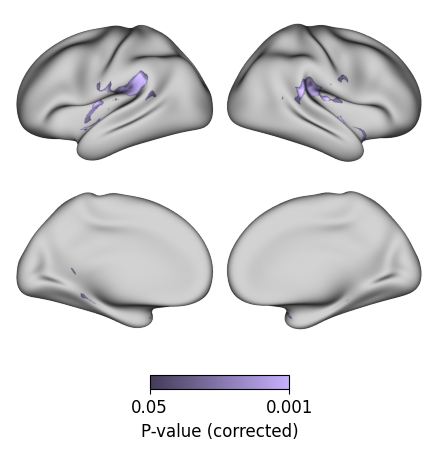

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from surfplot import Plot
from pyvirtualdisplay import Display
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"
# Load both contrasts needed for conjunction
contrast_cong_audio = "congruent-audio"
contrast_cong_visual = "congruent-visual"
# Load positive results (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{contrast_cong_audio}/MNI152NLin2009cAsym/randomise_output_{contrast_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{contrast_cong_visual}/MNI152NLin2009cAsym/randomise_output_{contrast_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)
# Convert from (1-p) to p for both
nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)
# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)
# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)
# Transform results to fslr space 
fslr_conj = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
# Extract data arrays
fslr_lh_conj = fslr_conj[0].darrays[0].data.copy()
fslr_rh_conj = fslr_conj[1].darrays[0].data.copy()
# Threshold and cap data
# Keep where p < 0.05, cap at p_max
fslr_lh_conj[fslr_lh_conj > p_threshold] = np.nan
fslr_rh_conj[fslr_rh_conj > p_threshold] = np.nan
fslr_lh_conj[fslr_lh_conj < p_max] = p_max
fslr_rh_conj[fslr_rh_conj < p_max] = p_max
# Fetch surfaces and medial wall mask
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_conj[medial_mask_lh == 0] = np.nan
fslr_rh_conj[medial_mask_rh == 0] = np.nan
# Transform to log space
fslr_lh_data = -np.log10(fslr_lh_conj)
fslr_rh_data = -np.log10(fslr_rh_conj)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# #6f638f = (0.435, 0.388, 0.561) exact
# Scale: darker version at threshold, brighter at most sig (keeping exact ratios)
# Ratios: R:G:B = 0.78:0.69:1.0
dark_purple  = (0.26, 0.23, 0.34)   # ~60% of #6f638f — at threshold
light_purple = (0.78, 0.69, 1.0)    # Scaled to blue=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with LIGHTER BRAIN SURFACE
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, 
            cmap=cmap_custom, 
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
fig.savefig('glm_congruent_conjunction_audio_and_visual.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/reporting/_get_clusters_table.py:104: UserWarning:

Attention: At least one of the (sub)peaks falls outside of the cluster body. Identifying the nearest in-cluster voxel.




=== Cluster Table ===
   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1 -47.0 -33.0  21.0   3.699027               5897
1          1a -58.0 -25.0  19.0   3.699027                   
2          1b -58.0 -37.0  27.0   3.397933                   
3          1c -62.0 -18.0  19.0   3.096903                   
4           2  -5.0 -35.0  -7.0   3.699027               6818
..        ...   ...   ...   ...        ...                ...
77         55  29.0 -31.0  11.0   1.308035                  1
78         56  64.0 -14.0  25.0   1.308035                  1
79         57  35.0 -31.0   4.0   1.308035                  1
80         58  59.0 -58.0  14.0   1.308035                  3
81         59  33.0 -31.0   6.0   1.308035                  1

[82 rows x 6 columns]

=== Peak Anatomical Labels (Harvard-Oxford Cortical) ===
Peak (-47, -33, 21): Parietal Operculum Cortex
Peak (-58, -25, 19): Parietal Operculum Cortex
Peak (-58, -37, 27): Parietal Operculum Cortex
Peak (-62, 

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/datasets/atlas.py:288: UserWarning:

`legacy_format` will default to `False` in release 0.11. Dataset fetchers will then return pandas dataframes by default instead of recarrays.



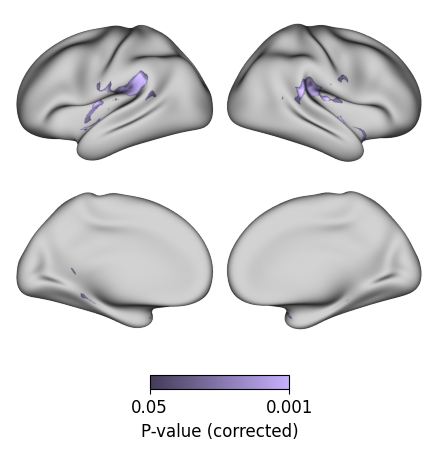

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image, datasets
from nilearn.reporting import get_clusters_table
from neuromaps import transforms
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"

# Load both contrasts needed for conjunction
contrast_cong_audio = "congruent-audio"
contrast_cong_visual = "congruent-visual"

# Load positive results (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{contrast_cong_audio}/MNI152NLin2009cAsym/randomise_output_{contrast_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{contrast_cong_visual}/MNI152NLin2009cAsym/randomise_output_{contrast_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)

# Convert from (1-p) to p for both
nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)

# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)

# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)

# ============================================================
# PEAK COORDINATE EXTRACTION
# ============================================================

# Create -log10(p) map for peak finding
conj_data = nii_conjunction_p.get_fdata()
neg_log_p = -np.log10(np.clip(conj_data, 1e-10, 1))  # avoid log(0)
neg_log_p[conj_data > p_threshold] = 0  # zero out non-significant voxels

neg_log_p_img = nib.Nifti1Image(neg_log_p, nii_conjunction_p.affine, nii_conjunction_p.header)

# Get cluster table with peak coordinates
table = get_clusters_table(neg_log_p_img, stat_threshold=-np.log10(p_threshold), 
                           min_distance=10)
print("\n=== Cluster Table ===")
print(table)

# Look up anatomical regions for each peak — Harvard-Oxford (cortical)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()
inv_affine = np.linalg.inv(atlas_img.affine)

print("\n=== Peak Anatomical Labels (Harvard-Oxford Cortical) ===")
for idx, row in table.iterrows():
    x, y, z = row['X'], row['Y'], row['Z']
    vox = np.round(inv_affine @ [x, y, z, 1])[:3].astype(int)
    if all(0 <= vox[i] < atlas_data.shape[i] for i in range(3)):
        label_idx = int(atlas_data[vox[0], vox[1], vox[2]])
        region = atlas.labels[label_idx] if label_idx > 0 else "No label (outside cortex)"
    else:
        region = "Outside atlas bounds"
    print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# Look up anatomical regions — Harvard-Oxford (subcortical)
atlas_sub = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
atlas_sub_img = atlas_sub.maps
atlas_sub_data = atlas_sub_img.get_fdata()
inv_affine_sub = np.linalg.inv(atlas_sub_img.affine)

print("\n=== Peak Anatomical Labels (Harvard-Oxford Subcortical) ===")
for idx, row in table.iterrows():
    x, y, z = row['X'], row['Y'], row['Z']
    vox = np.round(inv_affine_sub @ [x, y, z, 1])[:3].astype(int)
    if all(0 <= vox[i] < atlas_sub_data.shape[i] for i in range(3)):
        label_idx = int(atlas_sub_data[vox[0], vox[1], vox[2]])
        region = atlas_sub.labels[label_idx] if label_idx > 0 else "—"
    else:
        region = "Outside atlas bounds"
    if region != "—":
        print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# Look up anatomical regions — Destrieux (includes sulci like STS)
destrieux = datasets.fetch_atlas_destrieux_2009()
destrieux_img = nib.load(destrieux.maps)  # string path, needs nib.load()
destrieux_data = destrieux_img.get_fdata()
inv_affine_d = np.linalg.inv(destrieux_img.affine)

print("\n=== Peak Anatomical Labels (Destrieux — includes sulci) ===")
for idx, row in table.iterrows():
    x, y, z = row['X'], row['Y'], row['Z']
    vox = np.round(inv_affine_d @ [x, y, z, 1])[:3].astype(int)
    if all(0 <= vox[i] < destrieux_data.shape[i] for i in range(3)):
        label_idx = int(destrieux_data[vox[0], vox[1], vox[2]])
        if label_idx < len(destrieux.labels):
            region = destrieux.labels[label_idx]
        else:
            region = "Unknown"
    else:
        region = "Outside atlas bounds"
    print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# ============================================================
# SURFACE PLOTTING
# ============================================================

# Transform results to fslr space 
fslr_conj = transforms.mni152_to_fslr(nii_conjunction_p, '164k')

# Extract data arrays
fslr_lh_conj = fslr_conj[0].darrays[0].data.copy()
fslr_rh_conj = fslr_conj[1].darrays[0].data.copy()

# Threshold and cap data
fslr_lh_conj[fslr_lh_conj > p_threshold] = np.nan
fslr_rh_conj[fslr_rh_conj > p_threshold] = np.nan
fslr_lh_conj[fslr_lh_conj < p_max] = p_max
fslr_rh_conj[fslr_rh_conj < p_max] = p_max

# Fetch surfaces and medial wall mask
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_conj[medial_mask_lh == 0] = np.nan
fslr_rh_conj[medial_mask_rh == 0] = np.nan

# Transform to log space
fslr_lh_data = -np.log10(fslr_lh_conj)
fslr_rh_data = -np.log10(fslr_rh_conj)

# Calculate log thresholds
log_max = -np.log10(p_max)      # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Custom purple colormap
dark_purple  = (0.26, 0.23, 0.34)
light_purple = (0.78, 0.69, 1.0)

cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plot
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, 
            cmap=cmap_custom, 
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('glm_congruent_conjunction_audio_and_visual.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/datasets/atlas.py:288: UserWarning:

`legacy_format` will default to `False` in release 0.11. Dataset fetchers will then return pandas dataframes by default instead of recarrays.

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/reporting/_get_clusters_table.py:104: UserWarning:

Attention: At least one of the (sub)peaks falls outside of the cluster body. Identifying the nearest in-cluster voxel.




=== CONGRUENT > INCONGRUENT: Cluster Table ===
  Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0          1  -6.0  50.0  -2.0   1.801343               3761
1         1a   9.0  55.0  -5.0   1.588380                   
2         1b   3.0  47.0  13.0   1.503070                   
3         1c  10.0  58.0   4.0   1.468521                   
4          2   9.0  40.0 -15.0   1.387216                 58
5          3 -51.0 -37.0  20.0   1.366532                 53
6          4  47.0 -68.0 -11.0   1.364516                374
7         4a  56.0 -75.0  -4.0   1.309804                   
8          5 -45.0 -76.0  -9.0   1.331614                 71

=== CONGRUENT > INCONGRUENT: Harvard-Oxford Cortical ===
Peak (-6, 50, -2): Paracingulate Gyrus
Peak (9, 55, -5): No label (outside cortex)
Peak (3, 47, 13): Paracingulate Gyrus
Peak (10, 58, 4): Frontal Pole
Peak (9, 40, -15): No label (outside cortex)
Peak (-51, -37, 20): Planum Temporale
Peak (47, -68, -11): Lateral Occipital Cortex, in

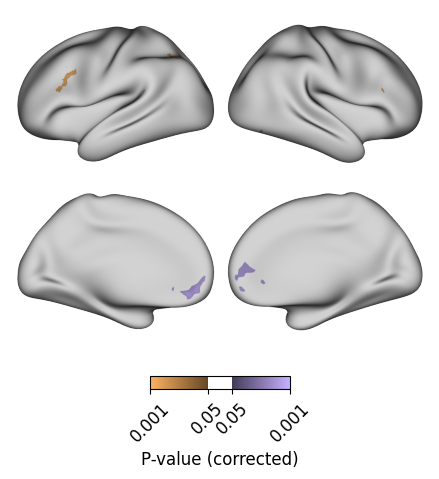

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image, datasets
from nilearn.reporting import get_clusters_table
from neuromaps import transforms
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from pyvirtualdisplay import Display

# Set font to Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs"
contrast = "congruent-incongruent"

# Load both positive and negative results (stored as 1-p in FSL)
fn_pos = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_neg = f"{glm_dir}/{contrast}/MNI152NLin2009cAsym/randomise_output_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat2.nii.gz"

nii_pos = nib.load(fn_pos)
nii_neg = nib.load(fn_neg)

# Convert from (1-p) to p for both
nii_pos_p = image.math_img('1 - X', X=nii_pos)
nii_neg_p = image.math_img('1 - X', X=nii_neg)

# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)

# ============================================================
# PEAK COORDINATE EXTRACTION
# ============================================================

# Load atlases
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()
inv_affine = np.linalg.inv(atlas_img.affine)

atlas_sub = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
atlas_sub_img = atlas_sub.maps
atlas_sub_data = atlas_sub_img.get_fdata()
inv_affine_sub = np.linalg.inv(atlas_sub_img.affine)

destrieux = datasets.fetch_atlas_destrieux_2009()
destrieux_img = nib.load(destrieux.maps)
destrieux_data = destrieux_img.get_fdata()
inv_affine_d = np.linalg.inv(destrieux_img.affine)

def lookup_peaks(table, direction_label):
    """Look up peak coordinates in all three atlases."""
    
    print(f"\n=== {direction_label}: Cluster Table ===")
    print(table)
    
    print(f"\n=== {direction_label}: Harvard-Oxford Cortical ===")
    for idx, row in table.iterrows():
        x, y, z = row['X'], row['Y'], row['Z']
        vox = np.round(inv_affine @ [x, y, z, 1])[:3].astype(int)
        if all(0 <= vox[i] < atlas_data.shape[i] for i in range(3)):
            label_idx = int(atlas_data[vox[0], vox[1], vox[2]])
            region = atlas.labels[label_idx] if label_idx > 0 else "No label (outside cortex)"
        else:
            region = "Outside atlas bounds"
        print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")
    
    print(f"\n=== {direction_label}: Harvard-Oxford Subcortical ===")
    for idx, row in table.iterrows():
        x, y, z = row['X'], row['Y'], row['Z']
        vox = np.round(inv_affine_sub @ [x, y, z, 1])[:3].astype(int)
        if all(0 <= vox[i] < atlas_sub_data.shape[i] for i in range(3)):
            label_idx = int(atlas_sub_data[vox[0], vox[1], vox[2]])
            region = atlas_sub.labels[label_idx] if label_idx > 0 else "—"
        else:
            region = "Outside atlas bounds"
        if region != "—":
            print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")
    
    print(f"\n=== {direction_label}: Destrieux (includes sulci) ===")
    for idx, row in table.iterrows():
        x, y, z = row['X'], row['Y'], row['Z']
        vox = np.round(inv_affine_d @ [x, y, z, 1])[:3].astype(int)
        if all(0 <= vox[i] < destrieux_data.shape[i] for i in range(3)):
            label_idx = int(destrieux_data[vox[0], vox[1], vox[2]])
            if label_idx < len(destrieux.labels):
                region = destrieux.labels[label_idx]
            else:
                region = "Unknown"
        else:
            region = "Outside atlas bounds"
        print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# --- Positive direction: congruent > incongruent ---
pos_data = nii_pos_p.get_fdata()
pos_neg_log_p = -np.log10(np.clip(pos_data, 1e-10, 1))
pos_neg_log_p[pos_data > p_threshold] = 0
pos_neg_log_p_img = nib.Nifti1Image(pos_neg_log_p, nii_pos_p.affine, nii_pos_p.header)

table_pos = get_clusters_table(pos_neg_log_p_img, stat_threshold=-np.log10(p_threshold),
                               min_distance=10)
lookup_peaks(table_pos, "CONGRUENT > INCONGRUENT")

# --- Negative direction: incongruent > congruent ---
neg_data = nii_neg_p.get_fdata()
neg_neg_log_p = -np.log10(np.clip(neg_data, 1e-10, 1))
neg_neg_log_p[neg_data > p_threshold] = 0
neg_neg_log_p_img = nib.Nifti1Image(neg_neg_log_p, nii_neg_p.affine, nii_neg_p.header)

table_neg = get_clusters_table(neg_neg_log_p_img, stat_threshold=-np.log10(p_threshold),
                               min_distance=10)
lookup_peaks(table_neg, "INCONGRUENT > CONGRUENT")

# ============================================================
# SURFACE PLOTTING
# ============================================================

# Transform results to fslr space FIRST
fslr_pos = transforms.mni152_to_fslr(nii_pos_p, '164k')
fslr_neg = transforms.mni152_to_fslr(nii_neg_p, '164k')

# Extract data arrays
fslr_lh_pos = fslr_pos[0].darrays[0].data.copy()
fslr_rh_pos = fslr_pos[1].darrays[0].data.copy()
fslr_lh_neg = fslr_neg[0].darrays[0].data.copy()
fslr_rh_neg = fslr_neg[1].darrays[0].data.copy()

# Threshold and create signed data
fslr_lh_pos[fslr_lh_pos > p_threshold] = np.nan
fslr_rh_pos[fslr_rh_pos > p_threshold] = np.nan
fslr_lh_pos[fslr_lh_pos < p_max] = p_max
fslr_rh_pos[fslr_rh_pos < p_max] = p_max

fslr_lh_neg[fslr_lh_neg > p_threshold] = np.nan
fslr_rh_neg[fslr_rh_neg > p_threshold] = np.nan
fslr_lh_neg[fslr_lh_neg < p_max] = p_max
fslr_rh_neg[fslr_rh_neg < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_pos[medial_mask_lh == 0] = np.nan
fslr_rh_pos[medial_mask_rh == 0] = np.nan
fslr_lh_neg[medial_mask_lh == 0] = np.nan
fslr_rh_neg[medial_mask_rh == 0] = np.nan

# Transform to log space — FIXED sign mapping
# Positive (congruent > incongruent) → positive values → purple side
# Negative (incongruent > congruent) → negative values → orange side
fslr_lh_pos_log = -np.log10(fslr_lh_pos)
fslr_rh_pos_log = -np.log10(fslr_rh_pos)
fslr_lh_neg_log = np.log10(fslr_lh_neg)
fslr_rh_neg_log = np.log10(fslr_rh_neg)

# Combine
fslr_lh_data = np.where(~np.isnan(fslr_lh_pos_log), fslr_lh_pos_log, fslr_lh_neg_log)
fslr_rh_data = np.where(~np.isnan(fslr_rh_pos_log), fslr_rh_pos_log, fslr_rh_neg_log)

# Calculate log thresholds
log_max = -np.log10(p_max)
log_threshold = -np.log10(p_threshold)

# Set values within threshold range to NaN
fslr_lh_data[(fslr_lh_data > -log_threshold) & (fslr_lh_data < log_threshold)] = np.nan
fslr_rh_data[(fslr_rh_data > -log_threshold) & (fslr_rh_data < log_threshold)] = np.nan

# Create colormap with SMALLER white gap
gap_scale = 0.4
pos_neg_threshold = (log_max - gap_scale * log_threshold) / (2 * log_max)
pos_pos_threshold = (log_max + gap_scale * log_threshold) / (2 * log_max)

tick_neg_threshold = -gap_scale * log_threshold
tick_pos_threshold = gap_scale * log_threshold

# PURPLE: congruent > incongruent (positive side)
dark_purple  = (0.26, 0.23, 0.34)
light_purple = (0.78, 0.69, 1.0)

# ORANGE: incongruent > congruent (negative side)
dark_orange  = (0.40, 0.28, 0.15)
light_orange = (1.0, 0.70, 0.38)

cdict = {
    'red':   [(0.0, light_orange[0], light_orange[0]),
              (pos_neg_threshold, dark_orange[0], 1.0),
              (pos_pos_threshold, 1.0, dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, light_orange[1], light_orange[1]),
              (pos_neg_threshold, dark_orange[1], 1.0),
              (pos_pos_threshold, 1.0, dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, light_orange[2], light_orange[2]),
              (pos_neg_threshold, dark_orange[2], 1.0),
              (pos_pos_threshold, 1.0, dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}

cmap_custom = LinearSegmentedColormap('custom_diverging', cdict)

kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)

p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, 
            cmap=cmap_custom, 
            color_range=(-log_max, log_max))

fig = p.build(cbar_kws=kws)

for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([-log_max, tick_neg_threshold, tick_pos_threshold, log_max])
        ax.set_xticklabels(['0.001', '0.05', '0.05', '0.001'], rotation=45, ha='center')

fig.savefig('glm_congruent_incongruent.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

# RSA Searchlight Plotting

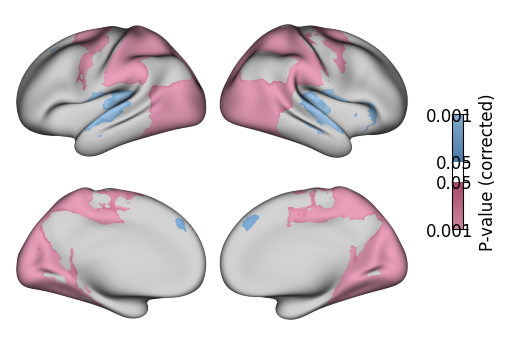

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Set Arial (Helvetica alternative) as the default font for all matplotlib text
# Arial is metrically compatible with Helvetica and more commonly available
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"

# Load both auditory-visual and visual-auditory results
fn_av = f"{glm_dir}/{category}/auditory-visual/randomise_output_{category}_auditory-visual_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_va = f"{glm_dir}/{category}/visual-auditory/randomise_output_{category}_visual-auditory_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii_av = nib.load(fn_av)
nii_va = nib.load(fn_va)

# Convert from (1-p) to p for both
nii_av_p = image.math_img('1 - X', X=nii_av)
nii_va_p = image.math_img('1 - X', X=nii_va)

# Define p-value thresholds
p_threshold = 0.05  # minimum p-value to show
p_max = 0.001       # maximum p-value (most significant)

# Transform results to fslr space FIRST
fslr_av = transforms.mni152_to_fslr(nii_av_p, '164k')
fslr_va = transforms.mni152_to_fslr(nii_va_p, '164k')

# Extract data arrays
fslr_lh_av = fslr_av[0].darrays[0].data.copy()
fslr_rh_av = fslr_av[1].darrays[0].data.copy()
fslr_lh_va = fslr_va[0].darrays[0].data.copy()
fslr_rh_va = fslr_va[1].darrays[0].data.copy()

# Threshold and create signed data
# Auditory-Visual: keep where p < 0.05, cap at p_max
fslr_lh_av[fslr_lh_av > p_threshold] = np.nan
fslr_rh_av[fslr_rh_av > p_threshold] = np.nan
fslr_lh_av[fslr_lh_av < p_max] = p_max
fslr_rh_av[fslr_rh_av < p_max] = p_max

# Visual-Auditory: keep where p < 0.05, cap at p_max
fslr_lh_va[fslr_lh_va > p_threshold] = np.nan
fslr_rh_va[fslr_rh_va > p_threshold] = np.nan
fslr_lh_va[fslr_lh_va < p_max] = p_max
fslr_rh_va[fslr_rh_va < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_av[medial_mask_lh == 0] = np.nan
fslr_rh_av[medial_mask_rh == 0] = np.nan
fslr_lh_va[medial_mask_lh == 0] = np.nan
fslr_rh_va[medial_mask_rh == 0] = np.nan

# Transform to log space (with correct sign)
# Auditory-Visual = positive side (blue)
fslr_lh_av_log = -np.log10(fslr_lh_av)
fslr_rh_av_log = -np.log10(fslr_rh_av)
# Visual-Auditory = negative side (rose)
fslr_lh_va_log = np.log10(fslr_lh_va)
fslr_rh_va_log = np.log10(fslr_rh_va)

# Combine: where auditory-visual exists use it, otherwise use visual-auditory
fslr_lh_data = np.where(~np.isnan(fslr_lh_av_log), fslr_lh_av_log, fslr_lh_va_log)
fslr_rh_data = np.where(~np.isnan(fslr_rh_av_log), fslr_rh_av_log, fslr_rh_va_log)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Set values within threshold range to NaN
fslr_lh_data[(fslr_lh_data > -log_threshold) & (fslr_lh_data < log_threshold)] = np.nan
fslr_rh_data[(fslr_rh_data > -log_threshold) & (fslr_rh_data < log_threshold)] = np.nan

# Create colormap with SMALLER white gap
# Reduce the white gap to 40% of the original size
gap_scale = 0.4
pos_neg_threshold = (log_max - gap_scale * log_threshold) / (2 * log_max)
pos_pos_threshold = (log_max + gap_scale * log_threshold) / (2 * log_max)

# Calculate actual tick positions based on colormap positions
tick_neg_threshold = -gap_scale * log_threshold
tick_pos_threshold = gap_scale * log_threshold

# SAME COLORS AS GLM UNISENSORY - Rose and Steel Blue, half range
# Rose side - half range
dark_rose   = (0.65, 0.28, 0.42)   # Dark rose — near threshold (less sig)
bright_rose = (0.80, 0.52, 0.62)   # Midpoint — at extremes (most sig), stays rosy

# Steel blue side - half range
dark_blue   = (0.29, 0.48, 0.65)   # Dark steel blue — near threshold (less sig)
bright_blue = (0.52, 0.67, 0.80)   # Midpoint — at extremes (most sig), stays blue

# BRIGHTER = MORE SIGNIFICANT: bright at extremes, dark near center
cdict = {
    'red':   [(0.0, bright_rose[0], bright_rose[0]),
              (pos_neg_threshold, dark_rose[0], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[0]),
              (1.0, bright_blue[0], bright_blue[0])],
    'green': [(0.0, bright_rose[1], bright_rose[1]),
              (pos_neg_threshold, dark_rose[1], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[1]),
              (1.0, bright_blue[1], bright_blue[1])],
    'blue':  [(0.0, bright_rose[2], bright_rose[2]),
              (pos_neg_threshold, dark_rose[2], 1.0),
              (pos_pos_threshold, 1.0, dark_blue[2]),
              (1.0, bright_blue[2], bright_blue[2])]
}

cmap_custom = LinearSegmentedColormap('custom_diverging', cdict)

# Colorbar settings - changed location to 'right'
kws = {'location': 'right',
       'label_direction': 90,  # Rotate label for vertical orientation
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)

p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, 
            cmap=cmap_custom, 
            color_range=(-log_max, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set symmetric ticks
for ax in fig.axes:
    if hasattr(ax, 'get_ylabel'):
        ax.set_ylabel('P-value (corrected)', fontsize=12)
        ax.set_yticks([-log_max, tick_neg_threshold, tick_pos_threshold, log_max])
        ax.set_yticklabels(['0.001', '0.05', '0.05', '0.001'], rotation=0, ha='right')

fig.savefig('searchlight_contrasts_unisensory.svg')

# Stop virtual display when done
display.stop()

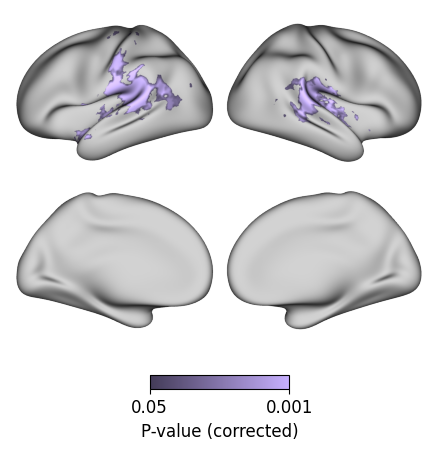

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from surfplot import Plot
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"

# Load both contrasts needed for conjunction
condition_cong_audio = "congruent-auditory"  # Adjust these names to match your actual files
condition_cong_visual = "congruent-visual"

# Load corrected p-values (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{category}/{condition_cong_audio}/randomise_output_{category}_{condition_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{category}/{condition_cong_visual}/randomise_output_{category}_{condition_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

# Load and convert from (1-p) to p
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)

nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)

# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform to log space
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Create sequential colormap: brighter = more significant
# MATCHING GLM conjunction colormap exactly
# #6f638f = (0.435, 0.388, 0.561) exact
# Scale: darker version at threshold, brighter at most sig (keeping exact ratios)
# Ratios: R:G:B = 0.78:0.69:1.0
dark_purple  = (0.26, 0.23, 0.34)   # ~60% of #6f638f — at threshold
light_purple = (0.78, 0.69, 1.0)    # Scaled to blue=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting with custom purple colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('rsa_conjunction_congruent_gt_audio_AND_visual.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/reporting/_get_clusters_table.py:104: UserWarning:

Attention: At least one of the (sub)peaks falls outside of the cluster body. Identifying the nearest in-cluster voxel.




=== Cluster Table ===
   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1 -51.0 -32.0  15.0   3.999928              40910
1          1a -66.0 -20.0  13.0   3.999928                   
2          1b -49.0 -43.0  10.0   3.522893                   
3          1c -41.0 -42.0  16.0   3.522893                   
4           2  54.0 -25.0  11.0   3.999928              26184
5          2a  44.0 -27.0  12.0   3.522893                   
6          2b  57.0 -33.0  -3.0   3.522893                   
7          2c  45.0 -24.0  14.0   3.522893                   
8           3  37.0  14.0 -10.0   2.366532                 51
9           4 -38.0 -15.0  21.0   1.863279                  6
10          5 -55.0 -66.0  13.0   1.667562                  2
11          6  42.0  20.0  16.0   1.490798                 97
12          7  41.0  16.0  23.0   1.444906                 34
13          8 -39.0 -12.0  16.0   1.435334                  1
14          9 -30.0 -25.0  71.0   1.435334     

/gpfs/milgram/project/turk-browne/or62/conda_envs/myenv_multimem/lib/python3.7/site-packages/nilearn/datasets/atlas.py:288: UserWarning:

`legacy_format` will default to `False` in release 0.11. Dataset fetchers will then return pandas dataframes by default instead of recarrays.



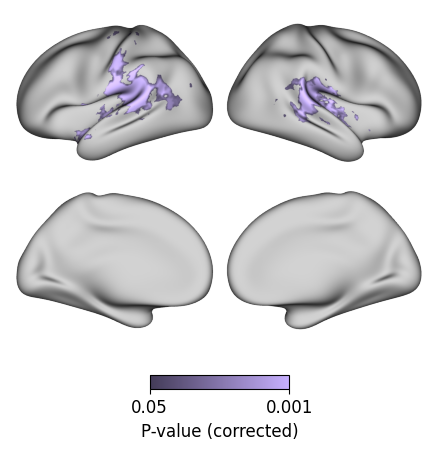

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image, datasets
from nilearn.reporting import get_clusters_table
from neuromaps import transforms
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"

# Load both contrasts needed for conjunction
condition_cong_audio = "congruent-auditory"
condition_cong_visual = "congruent-visual"

# Load corrected p-values (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{category}/{condition_cong_audio}/randomise_output_{category}_{condition_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{category}/{condition_cong_visual}/randomise_output_{category}_{condition_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

# Load and convert from (1-p) to p
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)

nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)

# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# ============================================================
# PEAK COORDINATE EXTRACTION
# ============================================================

# Create -log10(p) map for peak finding
conj_data = nii_conjunction_p.get_fdata()
neg_log_p = -np.log10(np.clip(conj_data, 1e-10, 1))
neg_log_p[conj_data > p_threshold] = 0

neg_log_p_img = nib.Nifti1Image(neg_log_p, nii_conjunction_p.affine, nii_conjunction_p.header)

# Get cluster table with peak coordinates
table = get_clusters_table(neg_log_p_img, stat_threshold=-np.log10(p_threshold), 
                           min_distance=10)
print("\n=== Cluster Table ===")
print(table)

# Load atlases
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()
inv_affine = np.linalg.inv(atlas_img.affine)

atlas_sub = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
atlas_sub_img = atlas_sub.maps
atlas_sub_data = atlas_sub_img.get_fdata()
inv_affine_sub = np.linalg.inv(atlas_sub_img.affine)

destrieux = datasets.fetch_atlas_destrieux_2009()
destrieux_img = nib.load(destrieux.maps)
destrieux_data = destrieux_img.get_fdata()
inv_affine_d = np.linalg.inv(destrieux_img.affine)

# Harvard-Oxford Cortical
print("\n=== Peak Anatomical Labels (Harvard-Oxford Cortical) ===")
for idx, row in table.iterrows():
    x, y, z = row['X'], row['Y'], row['Z']
    vox = np.round(inv_affine @ [x, y, z, 1])[:3].astype(int)
    if all(0 <= vox[i] < atlas_data.shape[i] for i in range(3)):
        label_idx = int(atlas_data[vox[0], vox[1], vox[2]])
        region = atlas.labels[label_idx] if label_idx > 0 else "No label (outside cortex)"
    else:
        region = "Outside atlas bounds"
    print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# Harvard-Oxford Subcortical
print("\n=== Peak Anatomical Labels (Harvard-Oxford Subcortical) ===")
for idx, row in table.iterrows():
    x, y, z = row['X'], row['Y'], row['Z']
    vox = np.round(inv_affine_sub @ [x, y, z, 1])[:3].astype(int)
    if all(0 <= vox[i] < atlas_sub_data.shape[i] for i in range(3)):
        label_idx = int(atlas_sub_data[vox[0], vox[1], vox[2]])
        region = atlas_sub.labels[label_idx] if label_idx > 0 else "—"
    else:
        region = "Outside atlas bounds"
    if region != "—":
        print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# Destrieux (includes sulci like STS)
print("\n=== Peak Anatomical Labels (Destrieux — includes sulci) ===")
for idx, row in table.iterrows():
    x, y, z = row['X'], row['Y'], row['Z']
    vox = np.round(inv_affine_d @ [x, y, z, 1])[:3].astype(int)
    if all(0 <= vox[i] < destrieux_data.shape[i] for i in range(3)):
        label_idx = int(destrieux_data[vox[0], vox[1], vox[2]])
        if label_idx < len(destrieux.labels):
            region = destrieux.labels[label_idx]
        else:
            region = "Unknown"
    else:
        region = "Outside atlas bounds"
    print(f"Peak ({x:.0f}, {y:.0f}, {z:.0f}): {region}")

# ============================================================
# SURFACE PLOTTING
# ============================================================

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform to log space
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)
log_threshold = -np.log10(p_threshold)

# Create sequential colormap
dark_purple  = (0.26, 0.23, 0.34)
light_purple = (0.78, 0.69, 1.0)

cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting with custom purple colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('rsa_conjunction_congruent_gt_audio_AND_visual.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import nibabel as nib
from nilearn import image
from neuromaps import transforms
from surfplot import Plot
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"

# Load both contrasts needed for conjunction
condition_cong_audio = "congruent-auditory"  # Adjust these names to match your actual files
condition_cong_visual = "congruent-visual"

# Load corrected p-values (stored as 1-p in FSL) for both contrasts
fn_cong_audio = f"{glm_dir}/{category}/{condition_cong_audio}/randomise_output_{category}_{condition_cong_audio}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn_cong_visual = f"{glm_dir}/{category}/{condition_cong_visual}/randomise_output_{category}_{condition_cong_visual}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

# Load and convert from (1-p) to p
nii_cong_audio = nib.load(fn_cong_audio)
nii_cong_visual = nib.load(fn_cong_visual)

nii_cong_audio_p = image.math_img('1 - X', X=nii_cong_audio)
nii_cong_visual_p = image.math_img('1 - X', X=nii_cong_visual)

# Conjunction: take the MAXIMUM p-value at each voxel (most conservative)
# This implements the "minimum statistic" conjunction (Nichols et al., 2005)
nii_conjunction_p = image.math_img('np.maximum(img1, img2)', 
                                    img1=nii_cong_audio_p, 
                                    img2=nii_cong_visual_p)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii_conjunction_p, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform to log space
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Create sequential colormap: brighter = more significant
# MATCHING GLM conjunction colormap exactly
light_purple = (0.92, 0.75, 1.0)    # Very bright lavender — at most significant
dark_purple  = (0.35, 0.10, 0.55)   # Deep saturated purple — at threshold
cdict = {
    'red':   [(0.0, dark_purple[0], dark_purple[0]),
              (1.0, light_purple[0], light_purple[0])],
    'green': [(0.0, dark_purple[1], dark_purple[1]),
              (1.0, light_purple[1], light_purple[1])],
    'blue':  [(0.0, dark_purple[2], dark_purple[2]),
              (1.0, light_purple[2], light_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting with custom purple colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('rsa_conjunction_congruent_gt_audio_AND_visual.svg', bbox_inches='tight')

# Stop virtual display when done
display.stop()

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


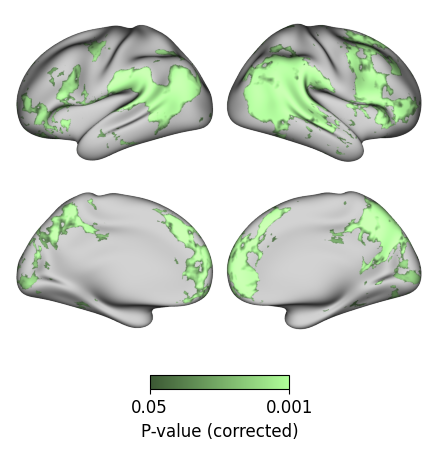

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np
# Set Helvetica as the default font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "contrasts"
condition = "unisensory_mean-incongruent_mean"
# Load corrected p-values (stored as 1-p in FSL)
fn = f"{glm_dir}/{category}/{condition}/randomise_output_{category}_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
# Load and convert from (1-p) to p
nii = nib.load(fn)
nii = image.math_img('1 - X', X=nii)  # Convert to regular p-values
# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)
# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii, '164k')
fslr_lh, fslr_rh = fslr
# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()
# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan
# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max
# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan
# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# GREEN colormap matching #6f638f purple scaling approach
# Purple: dark (0.26, 0.23, 0.34) -> light (0.78, 0.69, 1.0)
# Purple ratios: R:G:B = 0.78:0.69:1.0 (blue dominant)
# 
# For green, use same approach with green dominant
# Green ratios: R:G:B = 0.78:1.0:0.69 (green dominant, same relative ratios)
dark_green  = (0.23, 0.34, 0.20)    # ~60% — at threshold (matching purple's ~60%)
light_green = (0.69, 1.0, 0.60)     # Scaled to green=1.0 — at most significant

cdict = {
    'red':   [(0.0, dark_green[0], dark_green[0]),
              (1.0, light_green[0], light_green[0])],
    'green': [(0.0, dark_green[1], dark_green[1]),
              (1.0, light_green[1], light_green[1])],
    'blue':  [(0.0, dark_green[2], dark_green[2]),
              (1.0, light_green[2], light_green[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_green', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with custom colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12, family='Helvetica')
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
        # Ensure tick labels use Helvetica
        for label in ax.get_xticklabels():
            label.set_family('Helvetica')
fig.savefig('incongruency.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

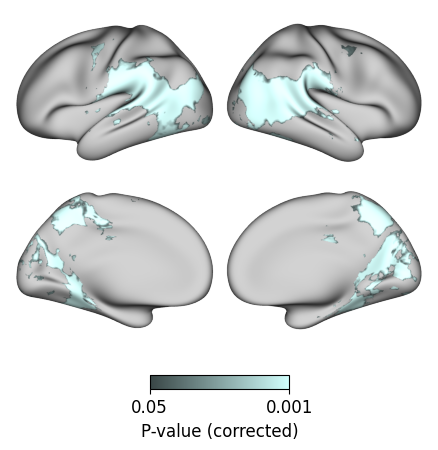

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np
# Set Helvetica as the default font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()
# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
category = "condition"
condition = "cross_visual_auditory"
# Load corrected p-values (stored as 1-p in FSL)
fn = f"{glm_dir}/{condition}/MNI152NLin2009cAsym/randomise_output_{category}_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
# Load and convert from (1-p) to p
nii = nib.load(fn)
nii = image.math_img('1 - X', X=nii)  # Convert to regular p-values
# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)
# Transform results to fslr space
fslr = transforms.mni152_to_fslr(nii, '164k')
fslr_lh, fslr_rh = fslr
# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()
# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan
# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max
# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan
# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)
# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# TEAL colormap matching #6f638f purple scaling approach
# #8caba9 = (0.549, 0.671, 0.663) — green dominant
# Ratios: R:G:B = 0.82:1.0:0.99 (normalized to green)
#
# Purple approach: ~60% at threshold, dominant channel to 1.0 at most sig
# Purple: dark (0.26, 0.23, 0.34) -> light (0.78, 0.69, 1.0)
dark_teal  = (0.22, 0.27, 0.27)    # ~40% of hex — at threshold (matching purple's ~60% scaling)
light_teal = (0.82, 1.0, 0.99)     # Green at 1.0, others scaled — at most significant

cdict = {
    'red':   [(0.0, dark_teal[0], dark_teal[0]),
              (1.0, light_teal[0], light_teal[0])],
    'green': [(0.0, dark_teal[1], dark_teal[1]),
              (1.0, light_teal[1], light_teal[1])],
    'blue':  [(0.0, dark_teal[2], dark_teal[2]),
              (1.0, light_teal[2], light_teal[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_teal', cdict)
# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}
# Plotting with custom colormap
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.6)
p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))
fig = p.build(cbar_kws=kws)
# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12, family='Helvetica')
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])
        # Ensure tick labels use Helvetica
        for label in ax.get_xticklabels():
            label.set_family('Helvetica')
fig.savefig('transfer.svg', bbox_inches='tight')
# Stop virtual display when done
display.stop()

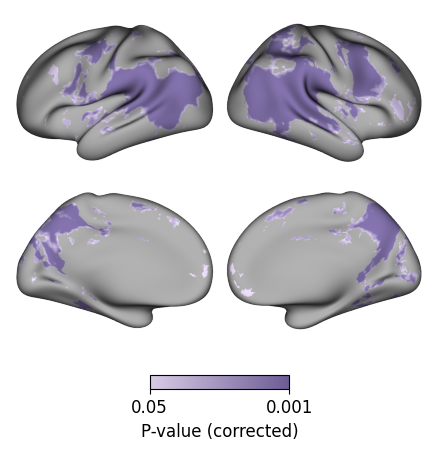

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import numpy as np

# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results/"
contrast1 = "visual"  
contrast2 = "auditory"

# Load both contrast results
fn1 = f"{glm_dir}/{contrast1}/MNI152NLin2009cAsym/randomise_output_condition_{contrast1}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn2 = f"{glm_dir}/{contrast2}/MNI152NLin2009cAsym/randomise_output_condition_{contrast2}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii1 = nib.load(fn1)
nii2 = nib.load(fn2)

# Convert from (1-p) to p for both
nii1_p = image.math_img('1 - X', X=nii1)
nii2_p = image.math_img('1 - X', X=nii2)

# Create strict conjunction: both must be significant at p < 0.05
# Take the maximum (worst) p-value where both are significant
p_threshold_conj = 0.05
conjunction = image.math_img(
    'np.where((X < 0.05) & (Y < 0.05), np.maximum(X, Y), 1)', 
    X=nii1_p, Y=nii2_p
)

# Define p-value thresholds
p_threshold = 0.05   # minimum p-value to show
p_max = 0.001        # maximum p-value (most significant)

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values above threshold to NaN (p > 0.05 = not significant)
fslr_lh_data[fslr_lh_data > p_threshold] = np.nan
fslr_rh_data[fslr_rh_data > p_threshold] = np.nan

# Cap values below max (most significant)
fslr_lh_data[fslr_lh_data < p_max] = p_max
fslr_rh_data[fslr_rh_data < p_max] = p_max

# Add medial wall masking
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Transform data to log scale for proper spacing
fslr_lh_data_log = -np.log10(fslr_lh_data)
fslr_rh_data_log = -np.log10(fslr_rh_data)

# Calculate log thresholds
log_max = -np.log10(p_max)  # ~3
log_threshold = -np.log10(p_threshold)  # ~1.3

# Create sequential colormap from light to dark purple
# Light purple to dark purple (#6b5b95)
light_purple = (0.85, 0.80, 0.90)  # Very light purple
dark_purple = (0.42, 0.36, 0.58)   # #6b5b95
cdict = {
    'red':   [(0.0, light_purple[0], light_purple[0]),
              (1.0, dark_purple[0], dark_purple[0])],
    'green': [(0.0, light_purple[1], light_purple[1]),
              (1.0, dark_purple[1], dark_purple[1])],
    'blue':  [(0.0, light_purple[2], light_purple[2]),
              (1.0, dark_purple[2], dark_purple[2])]
}
cmap_custom = LinearSegmentedColormap('sequential_purple', cdict)

# Colorbar settings
kws = {'location': 'bottom',
       'label_direction': 0,
       'fontsize': 12, 
       'aspect': 10,
       'draw_border': True}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

p.add_layer({'left': fslr_lh_data_log, 'right': fslr_rh_data_log}, 
            cmap=cmap_custom,
            color_range=(log_threshold, log_max))

fig = p.build(cbar_kws=kws)

# Add label and set ticks
for ax in fig.axes:
    if hasattr(ax, 'get_xlabel'):
        ax.set_xlabel('P-value (corrected)', fontsize=12)
        ax.set_xticks([log_threshold, log_max])
        ax.set_xticklabels(['0.05', '0.001'])

fig.savefig('unisensory_both.svg', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()

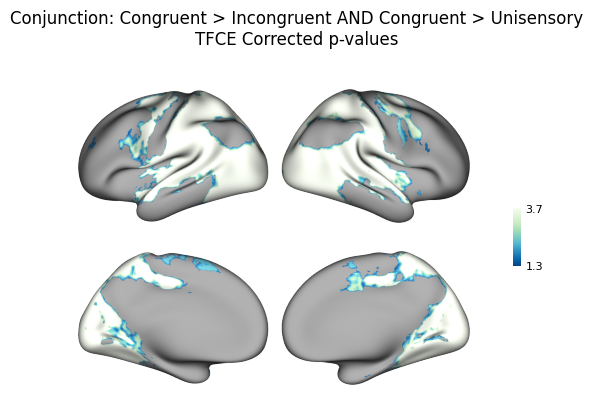

In [ ]:
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results/contrasts"
contrast1 = "congruent-incongruent_mean"  
contrast2 = "congruent-unisensory_mean"

# Load both contrast results
fn1 = f"{glm_dir}/{contrast1}/randomise_output_contrasts_{contrast1}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
fn2 = f"{glm_dir}/{contrast2}/randomise_output_contrasts_{contrast2}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"

nii1 = nib.load(fn1)
nii2 = nib.load(fn2)

# Create strict conjunction: both must be significant at p < 0.05
p_threshold = 0.001
thresh_value = 1 - p_threshold  # 0.95

conjunction = image.math_img(
    'np.where((X > 0.95) & (Y > 0.95), np.minimum(X, Y), 0)', 
    X=nii1, Y=nii2
)

# Transform to -log10(1-p) format
conjunction = image.math_img('-np.log10(1-X)', X=conjunction)

# Define p-value thresholds and their -log10 equivalents
p_threshold_viz = 0.05  # minimum p-value to show
p_max = 0.00001         # maximum p-value (most significant)
log_threshold = -np.log10(p_threshold_viz)  # ~1.3
log_max = -np.log10(p_max)                  # ~3.0

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values below threshold to NaN (won't be plotted)
fslr_lh_data[fslr_lh_data < log_threshold] = np.nan
fslr_rh_data[fslr_rh_data < log_threshold] = np.nan

# Optionally cap values above max
fslr_lh_data[fslr_lh_data > log_max] = log_max
fslr_rh_data[fslr_rh_data > log_max] = log_max

# Colorbar settings
kws = {'location': 'right', 'label_direction': 45, 'decimals': 1,
       'fontsize': 8, 'n_ticks': 2, 'shrink': .15, 'aspect': 8,
       'draw_border': False}

# Plotting
surfaces = fetch_fslr(density='164k')
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

# Add layer with conjunction data
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, cmap='GnBu_r')
fig = p.build(cbar_kws=kws)

# Add title
fig.suptitle('Conjunction: Congruent > Incongruent AND Congruent > Unisensory\nTFCE Corrected p-values', 
             fontsize=12, y=0.95)

fig.savefig('conjunction_brain_plot.png', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()

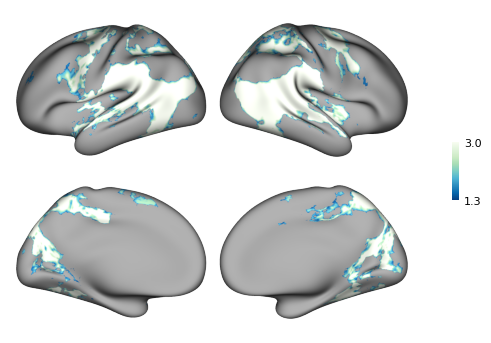

In [4]:
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir_base = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
glm_dir_contrasts = f"{glm_dir_base}/contrasts"

# Define conditions and contrasts as specified
conditions = ["auditory", "visual", "congruent"]
contrasts = ["congruent-unisensory_mean", "unisensory_mean-incongruent_mean"]

# Load all condition results
condition_niis = []
for condition in conditions:
    fn = f"{glm_dir_base}/{condition}/MNI152NLin2009cAsym/randomise_output_condition_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    condition_niis.append(nib.load(fn))

# Load contrast results
contrast_niis = []
for contrast in contrasts:
    fn = f"{glm_dir_contrasts}/{contrast}/randomise_output_contrasts_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    contrast_niis.append(nib.load(fn))

# Create conjunction: ALL conditions AND contrasts must be significant
p_threshold = 0.05
thresh_value = 1 - p_threshold  # 0.95

# Build the conjunction for 3 conditions + 2 contrasts = 5 total
conjunction = image.math_img(
    'np.where((A > 0.95) & (B > 0.95) & (C > 0.95) & (D > 0.95) & (E > 0.95), '
    'np.minimum(np.minimum(np.minimum(np.minimum(A, B), C), D), E), 0)',
    A=condition_niis[0],  # auditory
    B=condition_niis[1],  # visual  
    C=condition_niis[2],  # congruent
    D=contrast_niis[0],   # congruent-incongruent_mean
    E=contrast_niis[1]    # unisensory_mean-incongruent_mean
)

# Transform to -log10(1-p) format
conjunction = image.math_img('-np.log10(1-X)', X=conjunction)

# Define p-value thresholds and their -log10 equivalents
p_threshold_viz = 0.05  # minimum p-value to show
p_max = 0.001         # maximum p-value (most significant)
log_threshold = -np.log10(p_threshold_viz)  # ~1.3
log_max = -np.log10(p_max)                  # ~5.0

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values below threshold to NaN (won't be plotted)
fslr_lh_data[fslr_lh_data < log_threshold] = np.nan
fslr_rh_data[fslr_rh_data < log_threshold] = np.nan

# Optionally cap values above max
fslr_lh_data[fslr_lh_data > log_max] = log_max
fslr_rh_data[fslr_rh_data > log_max] = log_max

# **ADD MEDIAL WALL MASKING - MINIMAL ADDITION**
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Colorbar settings
kws = {'location': 'right', 'label_direction': 45, 'decimals': 1,
       'fontsize': 8, 'n_ticks': 2, 'shrink': .15, 'aspect': 8,
       'draw_border': False}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

# Add layer with conjunction data
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, cmap='GnBu_r')

fig = p.build(cbar_kws=kws)

# Add updated title

fig.savefig('multisensory_conjunction_brain_plot.png', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()

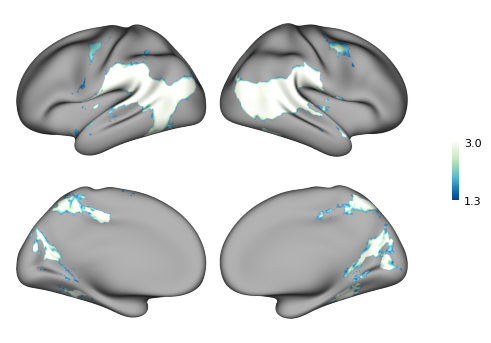

In [7]:
# Start virtual display
display = Display(visible=0, size=(1024, 768))
display.start()

# Load MNI-158 results
glm_dir_base = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/searchlight_rsa_results"
glm_dir_contrasts = f"{glm_dir_base}/contrasts"

# Define conditions and contrasts as specified
conditions = ["auditory", "visual", "congruent", "cross_visual_auditory"]
contrasts = ["congruent-unisensory_mean", "unisensory_mean-incongruent_mean"]

# Load all condition results
condition_niis = []
for condition in conditions:
    if condition == "cross_visual_auditory":
        fn = f"{glm_dir_base}/{condition}/MNI152NLin2009cAsym/randomise_output_condition_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    else:
        fn = f"{glm_dir_base}/{condition}/MNI152NLin2009cAsym/randomise_output_condition_{condition}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    condition_niis.append(nib.load(fn))

# Load contrast results
contrast_niis = []
for contrast in contrasts:
    fn = f"{glm_dir_contrasts}/{contrast}/randomise_output_contrasts_{contrast}_MNI152NLin2009cAsym_tfce_corrp_tstat1.nii.gz"
    contrast_niis.append(nib.load(fn))

# Create conjunction: ALL conditions AND contrasts must be significant
p_threshold = 0.05
thresh_value = 1 - p_threshold  # 0.95

# Build the conjunction for 4 conditions + 2 contrasts = 6 total
conjunction = image.math_img(
    'np.where((A > 0.95) & (B > 0.95) & (C > 0.95) & (D > 0.95) & (E > 0.95) & (F > 0.95), '
    'np.minimum(np.minimum(np.minimum(np.minimum(np.minimum(A, B), C), D), E), F), 0)',
    A=condition_niis[0],  # auditory
    B=condition_niis[1],  # visual  
    C=condition_niis[2],  # congruent
    D=condition_niis[3],  # cross_visual_auditory
    E=contrast_niis[0],   # congruent-unisensory_mean
    F=contrast_niis[1]    # unisensory_mean-incongruent_mean
)

# Transform to -log10(1-p) format
conjunction = image.math_img('-np.log10(1-X)', X=conjunction)

# Define p-value thresholds and their -log10 equivalents
p_threshold_viz = 0.05  # minimum p-value to show
p_max = 0.001         # maximum p-value (most significant)
log_threshold = -np.log10(p_threshold_viz)  # ~1.3
log_max = -np.log10(p_max)                  # ~3.0

# Transform results to fslr space
fslr = transforms.mni152_to_fslr(conjunction, '164k')
fslr_lh, fslr_rh = fslr

# Extract data arrays from GiftiImage objects and threshold them
fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

# Set values below threshold to NaN (won't be plotted)
fslr_lh_data[fslr_lh_data < log_threshold] = np.nan
fslr_rh_data[fslr_rh_data < log_threshold] = np.nan

# Optionally cap values above max
fslr_lh_data[fslr_lh_data > log_max] = log_max
fslr_rh_data[fslr_rh_data > log_max] = log_max

# **ADD MEDIAL WALL MASKING - MINIMAL ADDITION**
surfaces = fetch_fslr(density='164k')
medial_mask_lh = nib.load(surfaces['medial'][0]).agg_data()
medial_mask_rh = nib.load(surfaces['medial'][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

# Colorbar settings
kws = {'location': 'right', 'label_direction': 45, 'decimals': 1,
       'fontsize': 8, 'n_ticks': 2, 'shrink': .15, 'aspect': 8,
       'draw_border': False}

# Plotting
lh, rh = surfaces['inflated']
p = Plot(surf_lh=lh, surf_rh=rh)

# Add layer with conjunction data
p.add_layer({'left': fslr_lh_data, 'right': fslr_rh_data}, cmap='GnBu_r')

fig = p.build(cbar_kws=kws)

# Add updated title
fig.savefig('multisensory_conjunction_brain_plot.png', dpi=300, bbox_inches='tight')

# Stop virtual display when done
display.stop()